# fastchem cond file

We assume N2+H2O (gas, water, ice) system using fastchem/fastchem_cond presets

In [1]:
from exogibbs.presets.fastchem_cond import chemsetup as condsetup
cond = condsetup()
from exogibbs.presets.fastchem import chemsetup as gassetup
gas = gassetup()


fastchem_cond presets in ExoGibbs
number of species: 186 elements: 28 molecules: 186
fastchem presets in ExoGibbs
number of species: 523 elements: 28 molecules: 495


In [2]:
gas_species = list(gas.species)
gas_system = ['H2O1', 'N2']
index_h2o_gas = gas_species.index('H2O1')  
index_n2_gas = gas_species.index('N2')

cond_species = list(cond.species)
cond_system = ['H2O(s,l)']
index_h2o_cond = cond_species.index('H2O(s,l)')  

In [4]:
from exogibbs.thermo.stoichiometry import build_formula_matrix
from exogibbs.utils.nameparser import set_elements_from_components
from exogibbs.utils.nameparser import generate_components_from_formula_list

components_g = generate_components_from_formula_list(gas_system)
elements = set_elements_from_components(components_g)
formula_matrix_gas = build_formula_matrix(components_g, elements)

print("Formula matrix (gas):")
print(formula_matrix_gas)

components_c = generate_components_from_formula_list(cond_system)
formula_matrix_cond = build_formula_matrix(components_c, elements)

print("Formula matrix (cond):")
print(formula_matrix_cond)



Formula matrix (gas):
[[2 0]
 [1 0]
 [0 2]]
Formula matrix (cond):
[[2]
 [1]
 [0]]


(100,)


Text(0.5, 0, 'Temperature (K)')

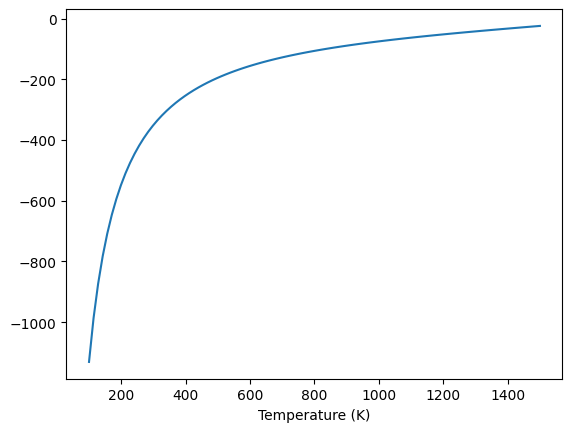

In [25]:
import matplotlib.pyplot as plt
import numpy as np
T = np.linspace(100, 1500, 100)
h2o_cond_h_values = cond.hvector_func(T)[:, index_h2o_cond] #mu_c(T)/RT
print(h2o_cond_h_values.shape)
plt.plot(T, h2o_cond_h_values, label='H2O Condensate h function (mu/RT)')

plt.xlabel('Temperature (K)')
